In [1]:
#############  price --------> BHK (PARAMETER) ##########################

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [5]:
#### loading the dataset

df=pd.read_csv('MagicBricks.csv')

In [6]:
df


,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [7]:
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   str    
 4   Locality     1259 non-null   str    
 5   Parking      1226 non-null   float64
 6   Price        1259 non-null   int64  
 7   Status       1259 non-null   str    
 8   Transaction  1259 non-null   str    
 9   Type         1254 non-null   str    
 10  Per_Sqft     1018 non-null   float64
dtypes: float64(4), int64(2), str(5)
memory usage: 108.3 KB


In [9]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1259.000000,1259.000000,1257.000000,1226.000000,1.259000e+03,1018.000000
mean,1466.452724,2.796664,2.556086,1.935563,2.130670e+07,15690.136542
std,1568.055040,0.954425,1.042220,6.279212,2.560115e+07,21134.738568
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.700000e+06,6364.000000
50%,1200.000000,3.000000,2.000000,1.000000,1.420000e+07,11291.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.550000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


In [11]:
df.shape

(1259, 11)

In [12]:
##### finding missing values

df.isnull().sum

<bound method DataFrame.sum of        Area    BHK  Bathroom  Furnishing  Locality  Parking  Price  Status  \
0     False  False     False       False     False    False  False   False   
1     False  False     False       False     False    False  False   False   
2     False  False     False       False     False    False  False   False   
3     False  False     False       False     False    False  False   False   
4     False  False     False       False     False    False  False   False   
...     ...    ...       ...         ...       ...      ...    ...     ...   
1254  False  False     False       False     False    False  False   False   
1255  False  False     False       False     False    False  False   False   
1256  False  False     False       False     False    False  False   False   
1257  False  False     False       False     False    False  False   False   
1258  False  False     False       False     False    False  False   False   

      Transaction   Type  Per_Sq

In [13]:
df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].median())

In [14]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [15]:
###### duplicates

df.duplicated().sum()

np.int64(83)

In [16]:
### remove duplicates

df.drop_duplicates(inplace=True)

In [17]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


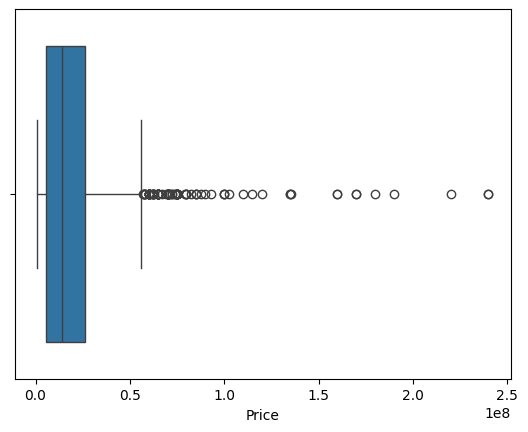

In [19]:
sns.boxplot(x=df['Price'])
plt.show()

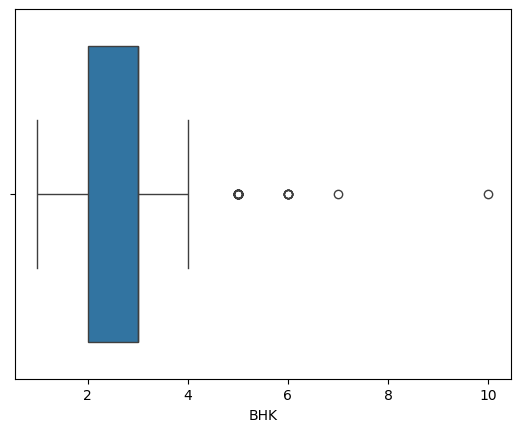

In [20]:
sns.boxplot(x=df['BHK'])
plt.show()

In [21]:
##### remove extreme outliers

df = df[df['BHK'] <= 6]

In [22]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [23]:
############ EDA ##############



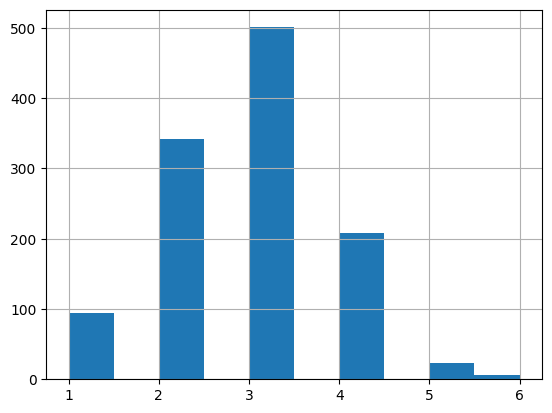

In [24]:
## DISTRUBUTION ANALYSIS

df['BHK'].hist()
plt.show()

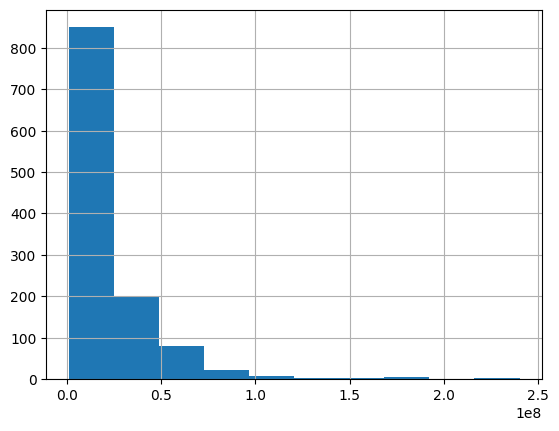

In [25]:
df['Price'].hist()
plt.show()

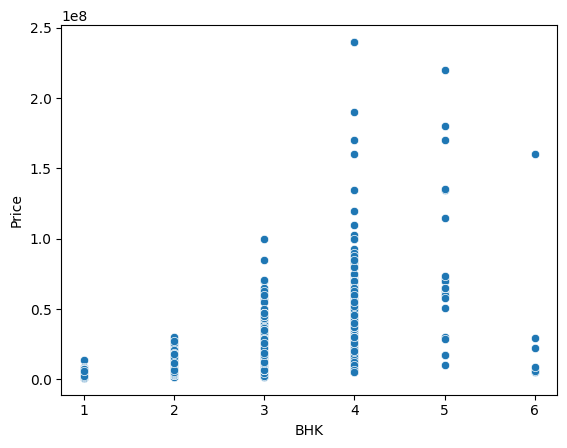

In [26]:
####### Relationship Analysis


sns.scatterplot(x='BHK',y='Price',data=df)
plt.show()

In [27]:
df[['BHK','Price']].corr()  ##### corelation

,BHK,Price
BHK,1.00000,0.58544
Price,0.58544,1.00000


In [28]:
####### feautre slection

x=df[['BHK']]
y=df['Price']

In [29]:
x

,BHK
0,3
1,2
2,2
3,2
4,2
...,...
1254,4
1255,3
1256,3
1257,2


In [30]:
y

0        6500000
1        5000000
2       15500000
3        4200000
4        6200000
          ...   
1254    55000000
1255    12500000
1256    17500000
1257    11500000
1258    18500000
Name: Price, Length: 1174, dtype: int64

In [32]:
######### split data 

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)


In [33]:
X_train

,BHK
914,3
271,4
645,3
191,3
694,3
...,...
1099,2
1180,2
1215,3
913,3


In [34]:
X_test

,BHK
428,3
449,4
727,2
217,2
864,3
...,...
43,2
682,2
251,4
1251,3


In [35]:
y_train

914      17000000
271      47500000
645      15500000
191      13500000
694      20000000
          ...    
1099      3800000
1180      4700000
1215     45000000
913       6200000
1211    135000000
Name: Price, Length: 939, dtype: int64

In [36]:
y_test

428     55300000
449     36500000
727     13200000
217      3000000
864      3800000
          ...   
43       7800000
682     27500000
251     90000000
1251    15500000
140     15000000
Name: Price, Length: 235, dtype: int64

In [37]:
model=LinearRegression()

In [38]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
y_pred=model.predict(X_test)

In [40]:
y_pred

array([24054513.01426253, 39023601.61622509,  9085424.41229996,
        9085424.41229996, 24054513.01426253, 24054513.01426253,
        9085424.41229996,  9085424.41229996,  9085424.41229996,
       24054513.01426253, 24054513.01426253, 39023601.61622509,
        9085424.41229996, 24054513.01426253,  9085424.41229996,
       39023601.61622509, 24054513.01426253, 24054513.01426253,
        9085424.41229996, 24054513.01426253,  9085424.41229996,
       24054513.01426253,  9085424.41229996, 24054513.01426253,
       39023601.61622509, -5883664.18966261, 39023601.61622509,
       24054513.01426253,  9085424.41229996,  9085424.41229996,
       -5883664.18966261, 24054513.01426253, 24054513.01426253,
       -5883664.18966261,  9085424.41229996, 24054513.01426253,
        9085424.41229996, 24054513.01426253, 68961778.82015024,
       24054513.01426253, 24054513.01426253, 24054513.01426253,
       24054513.01426253, 39023601.61622509, 24054513.01426253,
       24054513.01426253, 24054513.01426

In [41]:
model.predict([[3]])

C:\Users\KIIT\OneDrive\Desktop\mlprojects\machine-learning-projects\ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([24054513.01426253])

In [42]:
m=model.coef_[0]
b=model.intercept_

In [43]:
m

np.float64(14969088.60196257)

In [44]:
b

np.float64(-20852752.791625183)

In [45]:
price = m*3+b
print(price)

24054513.01426253


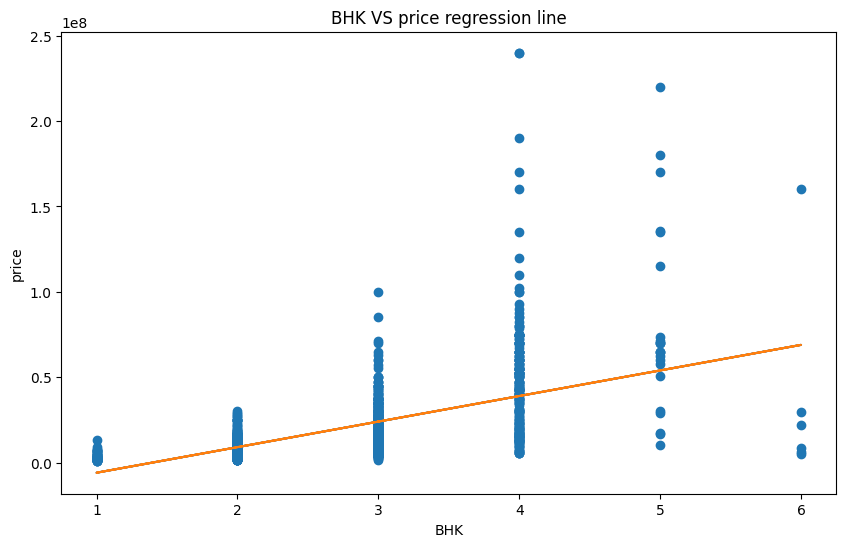

In [46]:
##### best fit line


plt.figure(figsize=(10,6))
plt.scatter(x,y)
plt.plot(x,model.predict(x))
plt.plot(x,model.predict(x))
plt.xlabel("BHK")
plt.ylabel("price")
plt.title("BHK VS price regression line")
plt.show()




In [48]:
## mean absolute error


mae = mean_absolute_error(y_test,y_pred)

print(mae)

## mean squared error

mse = mean_squared_error(y_test,y_pred)

print(mse)

### rmse 

rmse = np.sqrt(mse)

print(rmse)

### r2 score

r2=r2_score(y_test,y_pred)

print(r2)

14478570.624716233
730319124177656.9
27024417.18479155
0.3069832270255197


In [ ]:
####### bhk alone cannnot explain price of realstate